# Dashboard Analysis

Analysis of `MinerU_《赤红传说》92-111-收割死神_20251208_210006_dashboard.csv`.

In [2]:
%pip install matplotlib seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 6.3 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 5.6 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 4.7 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 4.6 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 4.9 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 5.2 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 6.3 MB/s eta 0:00:00
   ----------------------------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  # For Chinese characters support if needed
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# Load the dataset
filename = "MinerU_《赤红传说》92-111-收割死神_20251208_210006_dashboard.csv"
df = pd.read_csv(filename)

# Display first few rows
df.head()

,Paragraph_ID,Term_Matching_Time_s,API_Request_Time_s,Token_Usage,Timestamp
0,1,0.1081,20.5840,516,21:00:27
1,2,0.0207,99.6516,1267,21:02:06
2,3,0.0461,35.9060,949,21:02:42
3,4,0.0742,22.9831,804,21:03:05
4,5,0.1221,47.9979,1279,21:03:53


In [5]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Paragraph_ID          108 non-null    int64  
 1   Term_Matching_Time_s  108 non-null    float64
 2   API_Request_Time_s    108 non-null    float64
 3   Token_Usage           108 non-null    int64  
 4   Timestamp             108 non-null    object 
dtypes: float64(2), int64(2), object(1)
memory usage: 4.3+ KB


In [6]:
# Statistical summary
df.describe()

,Paragraph_ID,Term_Matching_Time_s,API_Request_Time_s,Token_Usage
count,108.00000,108.000000,108.000000,108.000000
mean,54.50000,0.054178,23.339899,789.092593
std,31.32092,0.049243,18.303073,420.175543
min,1.00000,0.015100,1.928600,312.000000
25%,27.75000,0.017950,7.957775,443.500000
50%,54.50000,0.026250,21.237000,662.500000
75%,81.25000,0.088800,32.789250,1103.500000
max,108.00000,0.191500,99.651600,1703.000000


## Performance Metrics Visualization

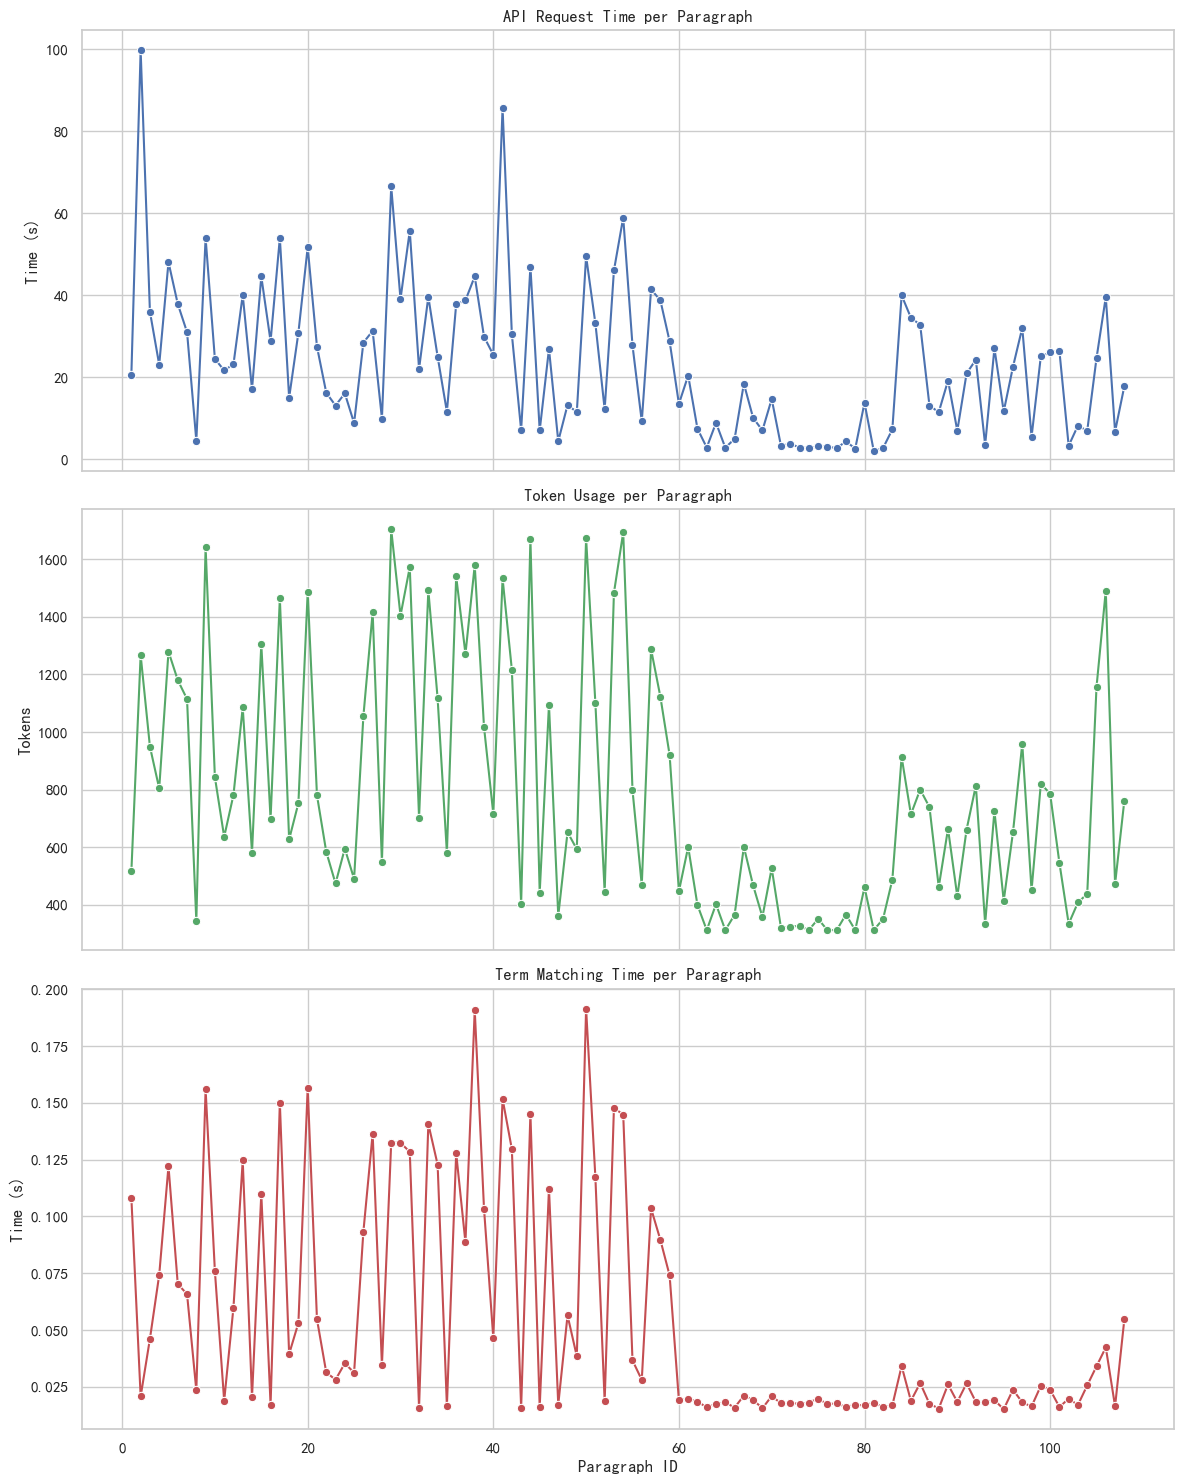

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# Plot 1: API Request Time
sns.lineplot(data=df, x='Paragraph_ID', y='API_Request_Time_s', ax=axes[0], marker='o', color='b')
axes[0].set_title('API Request Time per Paragraph')
axes[0].set_ylabel('Time (s)')

# Plot 2: Token Usage
sns.lineplot(data=df, x='Paragraph_ID', y='Token_Usage', ax=axes[1], marker='o', color='g')
axes[1].set_title('Token Usage per Paragraph')
axes[1].set_ylabel('Tokens')

# Plot 3: Term Matching Time
sns.lineplot(data=df, x='Paragraph_ID', y='Term_Matching_Time_s', ax=axes[2], marker='o', color='r')
axes[2].set_title('Term Matching Time per Paragraph')
axes[2].set_ylabel('Time (s)')
axes[2].set_xlabel('Paragraph ID')

plt.tight_layout()
plt.show()

## Correlation Analysis

Checking if there is a relationship between Token Usage and API Request Time.

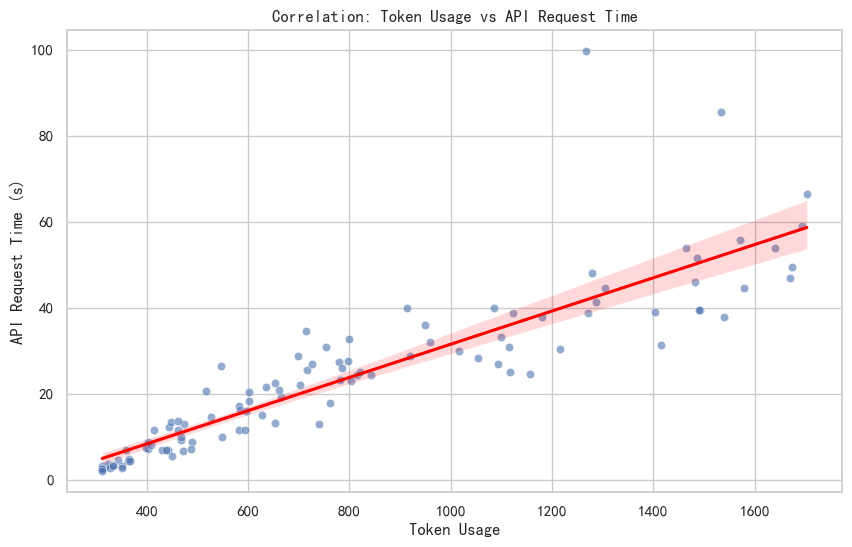

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Token_Usage', y='API_Request_Time_s', alpha=0.6)
sns.regplot(data=df, x='Token_Usage', y='API_Request_Time_s', scatter=False, color='red')
plt.title('Correlation: Token Usage vs API Request Time')
plt.xlabel('Token Usage')
plt.ylabel('API Request Time (s)')
plt.show()

In [9]:
correlation = df[['Token_Usage', 'API_Request_Time_s', 'Term_Matching_Time_s']].corr()
print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                      Token_Usage  API_Request_Time_s  Term_Matching_Time_s
Token_Usage              1.000000            0.886907              0.876670
API_Request_Time_s       0.886907            1.000000              0.709271
Term_Matching_Time_s     0.876670            0.709271              1.000000
